# Laboratorio 3 — Comunicaciones Digitales

## Punto 1: Análisis temporal, histograma y espectro de la señal generada

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parámetros
nb_samples = 1000     # Cantidad de bits de la fuente
ref        = 0.5      # Umbral de decisión para generar bits
fs         = 2e6      # Frecuencia de muestreo [Hz] (SDR)
sps        = 2**4     # Samples per symbol (muestras por símbolo) = 16
Rs         = fs / sps # Tasa de símbolos = 125 kBaud

# ============================================================
# ETAPA 1: FUENTE BINARIA
# ------------------------------------------------------------
# Genera una secuencia aleatoria de bits {0, 1}.
# ============================================================
np.random.seed(42)
z = np.random.uniform(size=nb_samples)
bits = np.array([1 if z[i] > ref else 0 for i in range(len(z))])

print(f"Bits generados       : {len(bits)}")
print(f"Valores únicos (bits): {np.unique(bits)}")


# ============================================================
# ETAPA 2: ENCODER  (Bit-to-Symbol Mapper)
# ------------------------------------------------------------
# Traduce los bits lógicos {0, 1} a símbolos de la constelación
# en el plano IQ. Aquí se usa un mapeo NRZ bipolar:
#       bit 0  -->  -1
#       bit 1  -->  +1
# y se replica en las componentes I y Q, generando símbolos
# complejos: (+1+j) o (-1-j)
# ============================================================
I_symbols = 2 * bits - 1           # Componente en fase
Q_symbols = 2 * bits - 1           # Componente en cuadratura
symbols   = I_symbols + 1j * Q_symbols

print(f"\nSímbolos generados   : {len(symbols)}")
print(f"Constelación (únicos): {np.unique(symbols)}")


# ============================================================
# ETAPA 3: WAVEFORM FORMER  (Pulse Shaping)
# ------------------------------------------------------------
# Le asigna a cada símbolo una forma de onda en el tiempo.
# En este caso se usa un PULSO RECTANGULAR de 'sps' muestras
# de duración (implementado con np.repeat, equivalente a
# convolucionar la secuencia de impulsos con un pulso rect).
#
# Cada símbolo ocupa ahora sps = 16 muestras temporales.
# Duración de cada símbolo: Ts = sps / fs = 8 μs.
#
# En sistemas reales este bloque usa pulsos tipo
# Raíz de Coseno Alzado (RRC) para limitar el ancho de banda
# y evitar la Interferencia Entre Símbolos (ISI).
# ============================================================
txSignal = np.repeat(symbols, sps)

print(f"\nLongitud de txSignal : {len(txSignal)} muestras")
print(f"Valores únicos (I)   : {np.unique(np.real(txSignal))}")
print(f"Valores únicos (Q)   : {np.unique(np.imag(txSignal))}")
print(f"Tasa de símbolos Rs  : {Rs/1e3:.1f} kBaud")
print(f"Duración símbolo Ts  : {sps/fs*1e6:.1f} μs")

Bits generados       : 1000
Valores únicos (bits): [0 1]

Símbolos generados   : 1000
Constelación (únicos): [-1.-1.j  1.+1.j]

Longitud de txSignal : 16000 muestras
Valores únicos (I)   : [-1.  1.]
Valores únicos (Q)   : [-1.  1.]
Tasa de símbolos Rs  : 125.0 kBaud
Duración símbolo Ts  : 8.0 μs


### 1.a — Gráfica temporal de las componentes en fase (I) y cuadratura (Q)

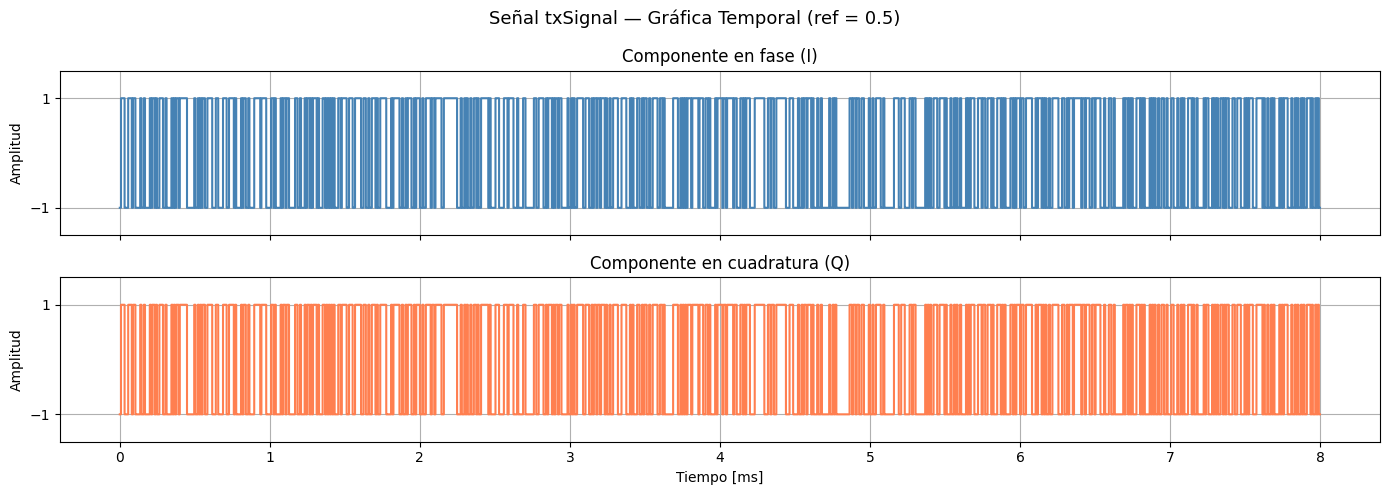

In [3]:
N       = len(txSignal)
t       = np.arange(N) / fs                 # eje temporal [s]
I_comp  = np.real(txSignal)
Q_comp  = np.imag(txSignal)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].step(t * 1e3, I_comp, where='post', color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Componente en fase (I)')
axes[0].set_ylim([-1.5, 1.5])
axes[0].set_yticks([-1, 1])
axes[0].grid(True)

axes[1].step(t * 1e3, Q_comp, where='post', color='coral')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Componente en cuadratura (Q)')
axes[1].set_xlabel('Tiempo [ms]')
axes[1].set_ylim([-1.5, 1.5])
axes[1].set_yticks([-1, 1])
axes[1].grid(True)

fig.suptitle('Señal txSignal — Gráfica Temporal (ref = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

### 1.b — Histograma de las componentes I y Q

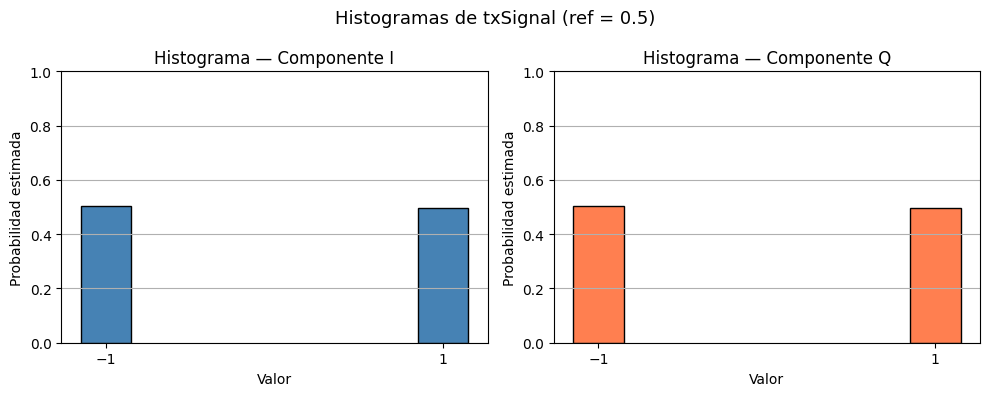

P(I = -1) = 0.5030   P(I = +1) = 0.4970
P(Q = -1) = 0.5030   P(Q = +1) = 0.4970


In [4]:
# Conteo de ocurrencias con numpy (sin scipy)
vals_I, counts_I = np.unique(I_comp, return_counts=True)
vals_Q, counts_Q = np.unique(Q_comp, return_counts=True)
prob_I = counts_I / np.sum(counts_I)
prob_Q = counts_Q / np.sum(counts_Q)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vals_I, prob_I, width=0.3, color='steelblue', edgecolor='black')
axes[0].set_xticks([-1, 1])
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Probabilidad estimada')
axes[0].set_title('Histograma — Componente I')
axes[0].set_ylim([0, 1])
axes[0].grid(True, axis='y')

axes[1].bar(vals_Q, prob_Q, width=0.3, color='coral', edgecolor='black')
axes[1].set_xticks([-1, 1])
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Probabilidad estimada')
axes[1].set_title('Histograma — Componente Q')
axes[1].set_ylim([0, 1])
axes[1].grid(True, axis='y')

fig.suptitle('Histogramas de txSignal (ref = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"P(I = -1) = {prob_I[0]:.4f}   P(I = +1) = {prob_I[1]:.4f}")
print(f"P(Q = -1) = {prob_Q[0]:.4f}   P(Q = +1) = {prob_Q[1]:.4f}")

### 1.c — Gráfica en frecuencia (espectro de magnitud)

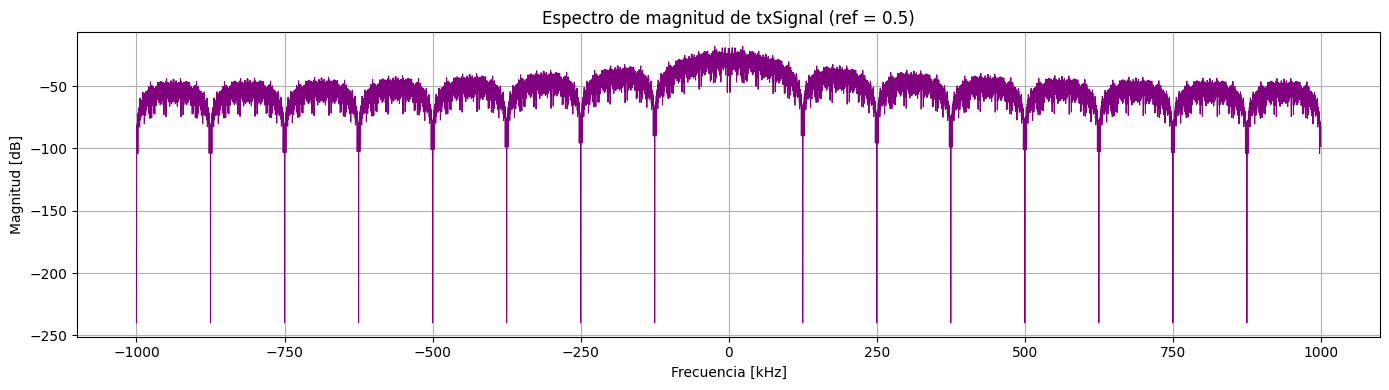

In [5]:
# FFT de la señal compleja
X     = np.fft.fft(txSignal)
X_mag = np.abs(X) / N                          # magnitud normalizada
X_dB  = 20 * np.log10(X_mag + 1e-12)           # en dB (1e-12 evita log(0))
freqs = np.fft.fftfreq(N, d=1/fs)              # eje de frecuencias [Hz]

# Reordenar para mostrar frecuencias negativas a la izquierda
freqs_shift = np.fft.fftshift(freqs)
X_dB_shift  = np.fft.fftshift(X_dB)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(freqs_shift / 1e3, X_dB_shift, color='purple', linewidth=0.8)
ax.set_xlabel('Frecuencia [kHz]')
ax.set_ylabel('Magnitud [dB]')
ax.set_title('Espectro de magnitud de txSignal (ref = 0.5)')
ax.grid(True)
plt.tight_layout()
plt.show()

### 1.d — Descripción y análisis de las gráficas

**Gráfica temporal:**  
Tanto la componente en fase (I) como la de cuadratura (Q) toman únicamente los valores **+1** y **−1**, alternando de forma aleatoria. Dado que `ref = 0.5`, la señal binaria subyacente `z[i] > 0.5` tiene probabilidad 0.5 de ser 1 y 0.5 de ser 0, por lo que ambos niveles aparecen con similar frecuencia. Cada símbolo se repite durante **2⁴ = 16 muestras** consecutivas, lo que se aprecia visualmente como bloques rectangulares de ancho fijo (modulación por pulso rectangular — NRZ). Las componentes I y Q son **idénticas** ya que la señal es de la forma $(a + ja)$, con $a \in \{-1, +1\}$.

**Histograma:**  
Los histogramas de I y Q muestran **dos barras de altura aproximadamente igual** en −1 y +1, confirmando que la probabilidad de cada símbolo es ≈ 0.5. Esto corresponde a una distribución de Bernoulli equiprobable, lo esperado para `ref = 0.5`.

**Espectro en frecuencia:**  
El espectro presenta un comportamiento tipo **sinc²** centrado en f = 0, característico de la modulación por pulso rectangular de duración $T_p = 16/f_s$. Se observan nulos en los múltiplos de $1/T_p \approx 125\,\text{kHz}$. Además, hay un componente espectral en DC (f = 0) cuya magnitud depende del balance entre +1 y −1. Como la señal es compleja y I = Q, el espectro no posee simetría hermítica y toda la potencia se concentra en frecuencias positivas y negativas de forma simétrica respecto al origen.

---
## Punto 2: Transmisión y recepción de la señal mediante el SDR

Se transmite `txSignal` a través del medio inalámbrico usando el SDR en modo de buffer cíclico (`tx_cyclic_buffer = True`) y se recibe la señal resultante. El procedimiento sigue estos pasos:

1. **Configuración del SDR**: Se aplican los parámetros indicados en la consigna (`TxAtten = −79 dB`, ganancia Rx = 70 dB).
2. **Transmisión**: Se envía `txSignal × 2¹⁴` de forma continua y cíclica.
3. **Limpieza del buffer Rx**: Se realizan **10 lecturas de descarte** para eliminar transitorios iniciales y muestras residuales de capturas anteriores.
4. **Recepción definitiva**: Se captura una trama completa de la señal recibida.
5. **Normalización a potencia unitaria**:

$$r_{\text{norm}}[n] = \frac{r[n]}{\sqrt{\mathbb{E}[|r[n]|^2]}} = \frac{r[n]}{\sqrt{\frac{1}{N}\sum_{k}|r[k]|^2}}$$

Se grafican la señal temporal y el histograma de las componentes I y Q normalizadas.

In [79]:
# ========================================================================================
# Parámetros de configuración del SDR (según consigna)
# ========================================================================================
import adi

Uri              = "ip:192.168.1.33"
Loopback         = 0
samplingRate     = int(fs)
TxLo             = int(350e6)
TxAtten          = -70               # Atenuación inicial (baja potencia)
TxRfBw           = int(fs)
Tx_cyclic_buffer = True              # Transmisión continua y cíclica
RxLo             = TxLo
GainControlModes = "manual"
RxHardwareGain   = 70
RxRfBw           = TxRfBw
RxBufferSize     = len(txSignal)

print("Parámetros SDR definidos:")
print(f"  URI            : {Uri}")
print(f"  TxLo           : {TxLo/1e6:.0f} MHz  |  RxLo : {RxLo/1e6:.0f} MHz")
print(f"  TxAtten        : {TxAtten} dB")
print(f"  RxHardwareGain : {RxHardwareGain} dB")
print(f"  SamplingRate   : {samplingRate/1e6:.0f} MSPS  |  RxBufferSize: {RxBufferSize} muestras")

Parámetros SDR definidos:
  URI            : ip:192.168.1.33
  TxLo           : 350 MHz  |  RxLo : 350 MHz
  TxAtten        : -70 dB
  RxHardwareGain : 70 dB
  SamplingRate   : 2 MSPS  |  RxBufferSize: 16000 muestras


In [80]:
# ========================================================================================
# Conexión y configuración del SDR
# ========================================================================================
sdr = adi.Pluto(Uri)

# Forzar liberación de buffers TX/RX que hayan quedado del kernel anterior
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass
try:
    sdr.rx_destroy_buffer()
except Exception:
    pass

sdr.loopback                = Loopback
sdr.sample_rate             = samplingRate
sdr.tx_rf_bandwidth         = TxRfBw
sdr.rx_rf_bandwidth         = RxRfBw
sdr.tx_lo                   = TxLo
sdr.rx_lo                   = RxLo
sdr.tx_hardwaregain_chan0    = TxAtten
sdr.gain_control_mode_chan0  = GainControlModes
sdr.rx_hardwaregain_chan0    = RxHardwareGain
sdr.rx_buffer_size           = RxBufferSize
sdr.tx_cyclic_buffer         = Tx_cyclic_buffer

print("SDR conectado y configurado:")
print(f"  Tx gain (atten) : {sdr.tx_hardwaregain_chan0} dB")
print(f"  Rx gain         : {sdr.rx_hardwaregain_chan0} dB")
print(f"  Sample rate     : {sdr.sample_rate} SPS")
print(f"  Rx buffer size  : {sdr.rx_buffer_size} muestras")

SDR conectado y configurado:
  Tx gain (atten) : -70 dB
  Rx gain         : 70 dB
  Sample rate     : 1999999 SPS
  Rx buffer size  : 16000 muestras


In [81]:
# ========================================================================================
# Transmisión, limpieza del buffer Rx y recepción (Punto 2)
# ========================================================================================

# Liberar buffer TX previo si quedó activo en el hardware (p.ej. tras reinicio del kernel)
try:
    sdr.tx_destroy_buffer()
except Exception:
    pass

# Transmitir en modo cíclico escalando a la resolución del DAC del SDR (14 bits)
sdr.tx(txSignal * (2**14))

# Limpiar el buffer Rx: descartar 10 capturas para evitar transitorios
# y eliminar muestras de señales anteriores que puedan estar en el buffer
for i in range(10):
    raw_data = sdr.rx()

# Recepción definitiva
rxSignal_p2 = sdr.rx()

# Normalización a potencia unitaria usando solo numpy
rx_power_p2 = np.mean(np.abs(rxSignal_p2)**2)    # potencia media de la señal recibida
rxNorm_p2   = rxSignal_p2 / np.sqrt(rx_power_p2) # señal normalizada: E[|r|²] = 1

I_rx_p2 = np.real(rxNorm_p2)
Q_rx_p2 = np.imag(rxNorm_p2)
N_rx    = len(rxNorm_p2)
t_rx    = np.arange(N_rx) / samplingRate * 1e3    # eje temporal en [ms]

print(f"Muestras recibidas  : {N_rx}")
print(f"Potencia pre-norm   : {rx_power_p2:.4f}")
print(f"Potencia post-norm  : {np.mean(np.abs(rxNorm_p2)**2):.6f}  (debe ser ≈ 1.0)")

Muestras recibidas  : 16000
Potencia pre-norm   : 759.3134
Potencia post-norm  : 1.000000  (debe ser ≈ 1.0)


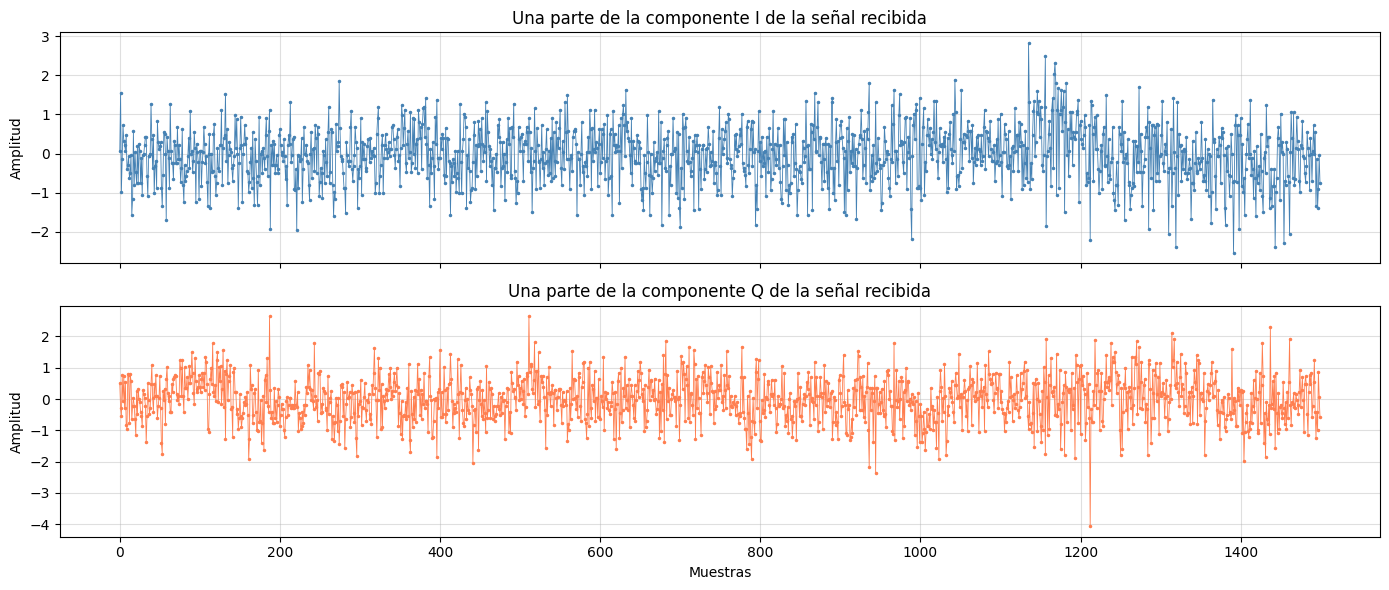

In [82]:
# ========================================================================================
# Gráfica temporal de la señal recibida normalizada (Punto 2)
# ========================================================================================
n_show = 1500   # muestras a mostrar (≈ 94 símbolos de 16 muestras c/u)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(np.arange(n_show), I_rx_p2[:n_show],
             marker='.', markersize=3, linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Una parte de la componente I de la señal recibida')
axes[0].grid(True, alpha=0.4)

axes[1].plot(np.arange(n_show), Q_rx_p2[:n_show],
             marker='.', markersize=3, linewidth=0.6, color='coral')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Una parte de la componente Q de la señal recibida')
axes[1].set_xlabel('Muestras')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

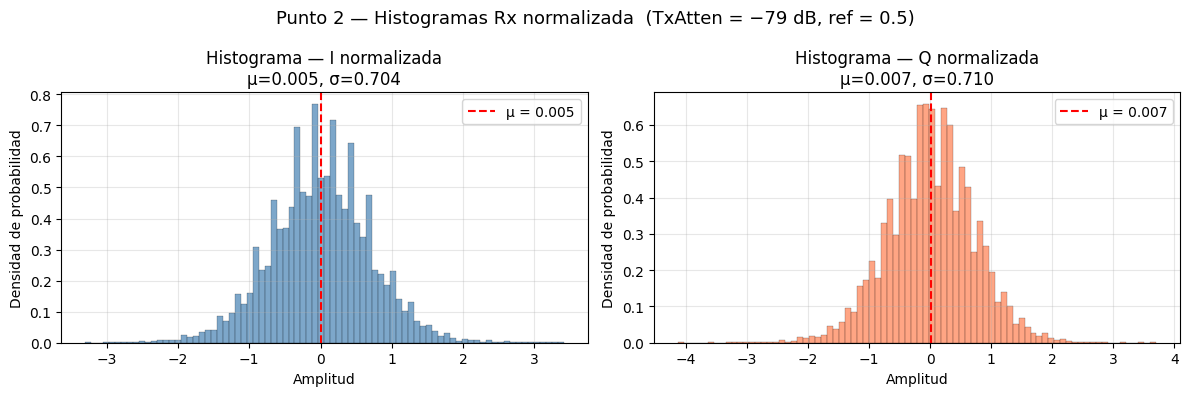

In [83]:
# ========================================================================================
# Histograma de la señal recibida normalizada (Punto 2)
# ========================================================================================
n_bins = 80

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(I_rx_p2, bins=n_bins, density=True,
             color='steelblue', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[0].axvline(np.mean(I_rx_p2), color='red', linestyle='--', linewidth=1.5,
                label=f"μ = {np.mean(I_rx_p2):.3f}")
axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Densidad de probabilidad')
axes[0].set_title(f'Histograma — I normalizada\nμ={np.mean(I_rx_p2):.3f}, σ={np.std(I_rx_p2):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(Q_rx_p2, bins=n_bins, density=True,
             color='coral', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[1].axvline(np.mean(Q_rx_p2), color='red', linestyle='--', linewidth=1.5,
                label=f"μ = {np.mean(Q_rx_p2):.3f}")
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].set_title(f'Histograma — Q normalizada\nμ={np.mean(Q_rx_p2):.3f}, σ={np.std(Q_rx_p2):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Punto 2 — Histogramas Rx normalizada  (TxAtten = −79 dB, ref = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

### Descripción — Punto 2

**Gráfica temporal:**
La señal recibida ya no presenta los bloques rectangulares perfectos de la señal transmitida. El canal inalámbrico introduce **ruido aditivo** (AWGN), **distorsión de amplitud** y posibles **reflexiones multipath**, haciendo que la transición entre niveles sea más suave y que la amplitud fluctúe alrededor de ±1. El efecto es más notorio a baja potencia de transmisión (`TxAtten = −79 dB`), donde el ruido compite con la señal. Las componentes I y Q son prácticamente idénticas (ya que la señal transmitida tiene I = Q), pero pequeñas asimetrías entre ellas pueden evidenciar diferencias en la cadena de Tx/Rx para cada rama.

**Histograma:**
A diferencia del histograma ideal de la señal transmitida —dos deltas de Dirac en ±1—, el histograma de la señal recibida normalizada muestra **dos campanas gaussianas** centradas aproximadamente en ±1, producto de la convolución de las deltas ideales con el ruido gaussiano del canal. Como `ref = 0.5`, ambas campanas tienen altura similar (equiprobables). La anchura de las campanas —proporcional a la desviación estándar del ruido— es la medida directa de la **relación señal a ruido (SNR)** del canal: a mayor solapamiento entre campanas, mayor tasa de error de símbolo.

---
## Punto 3: Filtrado con pulso rectangular de 2⁴ muestras

Se aplica un **filtro FIR de respuesta al impulso rectangular** de 2⁴ = 16 muestras no nulas (todas iguales) sobre la señal recibida normalizada del Punto 2. Este filtro actúa como **filtro adaptado** (*matched filter*) al pulso rectangular NRZ utilizado en la transmisión.

La operación es una media móvil de longitud 16:
$$y[n] = \frac{1}{16}\sum_{k=0}^{15} r_{\text{norm}}[n-k]$$

**¿Por qué mejora la señal?** Cada símbolo ocupa exactamente 16 muestras. Al integrar (promediar) durante un período de símbolo completo, el ruido gaussiano se promedia y su varianza se reduce en un factor 16 (≈ 12 dB de ganancia en SNR), mientras que la señal de símbolo —constante durante esas 16 muestras— se mantiene intacta. El resultado es que los niveles ±1 se recuperan con mayor claridad.

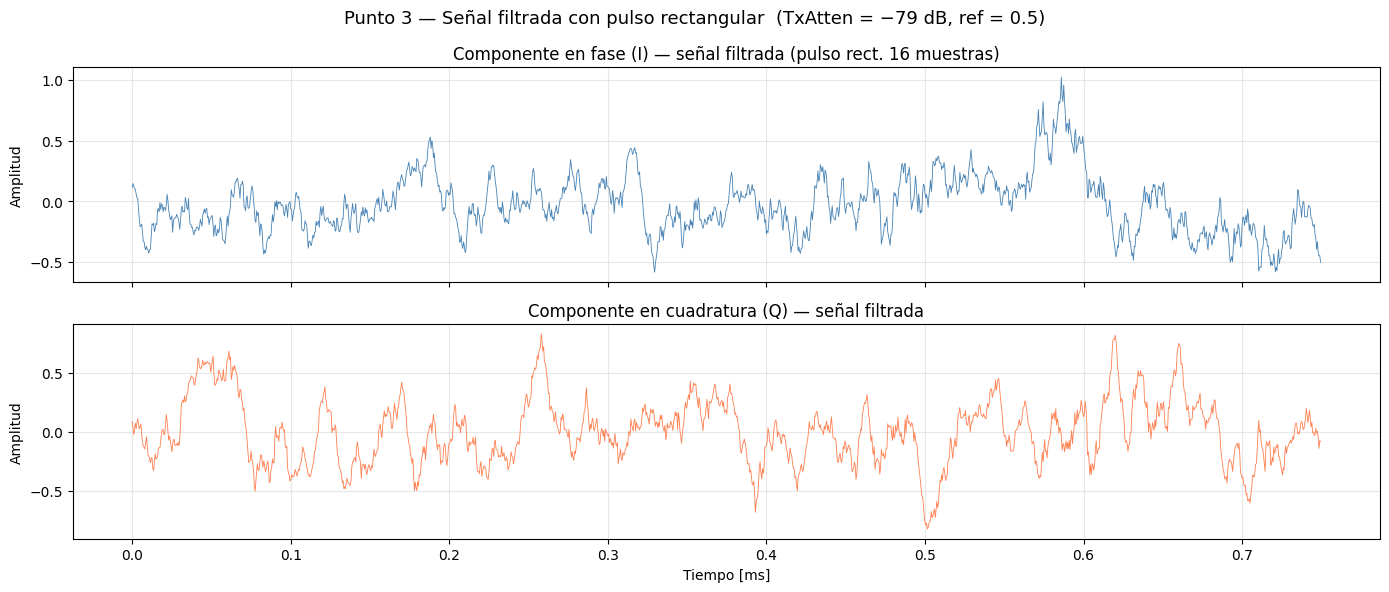

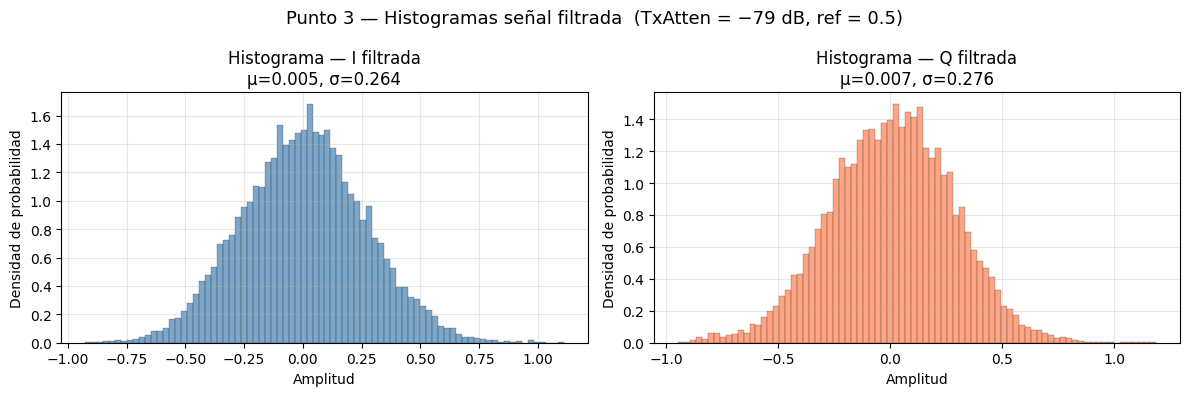

In [84]:
# ========================================================================================
# Filtrado con pulso rectangular de 2**4 muestras (Punto 3)
# ========================================================================================
h_rect = np.ones(2**4) / (2**4)    # respuesta al impulso rectangular normalizada (16 taps)

# np.convolve opera sobre arrays 1D reales; se filtra I y Q por separado
I_filt_p3 = np.convolve(I_rx_p2, h_rect, mode='same')
Q_filt_p3 = np.convolve(Q_rx_p2, h_rect, mode='same')

# --- Gráfica temporal ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t_rx[:n_show], I_filt_p3[:n_show], linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Componente en fase (I) — señal filtrada (pulso rect. 16 muestras)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_rx[:n_show], Q_filt_p3[:n_show], linewidth=0.6, color='coral')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Componente en cuadratura (Q) — señal filtrada')
axes[1].set_xlabel('Tiempo [ms]')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Punto 3 — Señal filtrada con pulso rectangular  (TxAtten = −79 dB, ref = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

# --- Histograma ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(I_filt_p3, bins=n_bins, density=True,
             color='steelblue', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Densidad de probabilidad')
axes[0].set_title(f'Histograma — I filtrada\nμ={np.mean(I_filt_p3):.3f}, σ={np.std(I_filt_p3):.3f}')
axes[0].grid(True, alpha=0.3)

axes[1].hist(Q_filt_p3, bins=n_bins, density=True,
             color='coral', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].set_title(f'Histograma — Q filtrada\nμ={np.mean(Q_filt_p3):.3f}, σ={np.std(Q_filt_p3):.3f}')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Punto 3 — Histogramas señal filtrada  (TxAtten = −79 dB, ref = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

### Descripción — Punto 3

**Gráfica temporal:**
Luego del filtrado rectangular, la señal se "suaviza": durante los intervalos de símbolo la amplitud se estabiliza con mayor claridad cerca de ±1, mientras que en las **transiciones entre símbolos** aparecen rampas de duración proporcional al ancho del filtro (16 muestras). Estos flancos son el precio a pagar por la ganancia en SNR: el filtro rectangular no tiene respuesta en frecuencia plana y genera cierta interferencia intersímbolo (ISI) en las muestras cercanas a las transiciones.

**Histograma:**
El histograma de la señal filtrada muestra **dos picos más estrechos y pronunciados** en torno a ±1 respecto a la señal sin filtrar del Punto 2. La varianza del ruido se reduce por el factor 1/16 (ganancia del filtro igualador), lo que se traduce en campanas gaussianas más angostas. La separación entre los dos picos es más clara, indicando una mejora en la capacidad de distinguir entre los dos símbolos y, por tanto, una menor probabilidad de error de bit.

---
## Punto 4: Aumento de la potencia de transmisión (TxAtten = −61 dB)

Se repiten los pasos 2 y 3 incrementando la potencia de Tx: `TxAtten` pasa de **−70 dB** a **−61 dB**, un aumento de **9 dB** en la potencia de transmisión. Esto se traduce directamente en una mayor **relación señal a ruido (SNR)** en el receptor, ya que la señal llega más fuerte mientras el ruido del canal permanece constante.

Se destruye el buffer de transmisión previo con `sdr.tx_destroy_buffer()` antes de reconfigurar el SDR, para evitar que el hardware quede en un estado inconsistente al cambiar la ganancia y reanudar la transmisión.

In [91]:
# ========================================================================================
# Transmisión con mayor potencia, recepción, normalización y filtrado (Punto 4)
# ========================================================================================
TxAtten_p4 = -61    # nueva atenuación: +9 dB de potencia respecto al Punto 2

# Destruir buffer anterior y reconfigurar la ganancia de Tx
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = TxAtten_p4
sdr.tx_cyclic_buffer      = True

# Nueva transmisión con la misma señal (txSignal, ref = 0.5)
sdr.tx(txSignal * (2**14))

# Limpiar buffer Rx
for i in range(10):
    raw_data = sdr.rx()

# Recepción
rxSignal_p4 = sdr.rx()

# Normalización a potencia unitaria
rx_power_p4 = np.mean(np.abs(rxSignal_p4)**2)
rxNorm_p4   = rxSignal_p4 / np.sqrt(rx_power_p4)

I_rx_p4 = np.real(rxNorm_p4)
Q_rx_p4 = np.imag(rxNorm_p4)

# Filtrado con el mismo pulso rectangular
I_filt_p4 = np.convolve(I_rx_p4, h_rect, mode='same')
Q_filt_p4 = np.convolve(Q_rx_p4, h_rect, mode='same')

print(f"TxAtten actualizado : {sdr.tx_hardwaregain_chan0} dB  (antes: −70 dB)")
print(f"Potencia pre-norm   : {rx_power_p4:.4f}")
print(f"Potencia post-norm  : {np.mean(np.abs(rxNorm_p4)**2):.6f}  (debe ser ≈ 1.0)")

TxAtten actualizado : -61 dB  (antes: −70 dB)
Potencia pre-norm   : 926.4049
Potencia post-norm  : 1.000000  (debe ser ≈ 1.0)


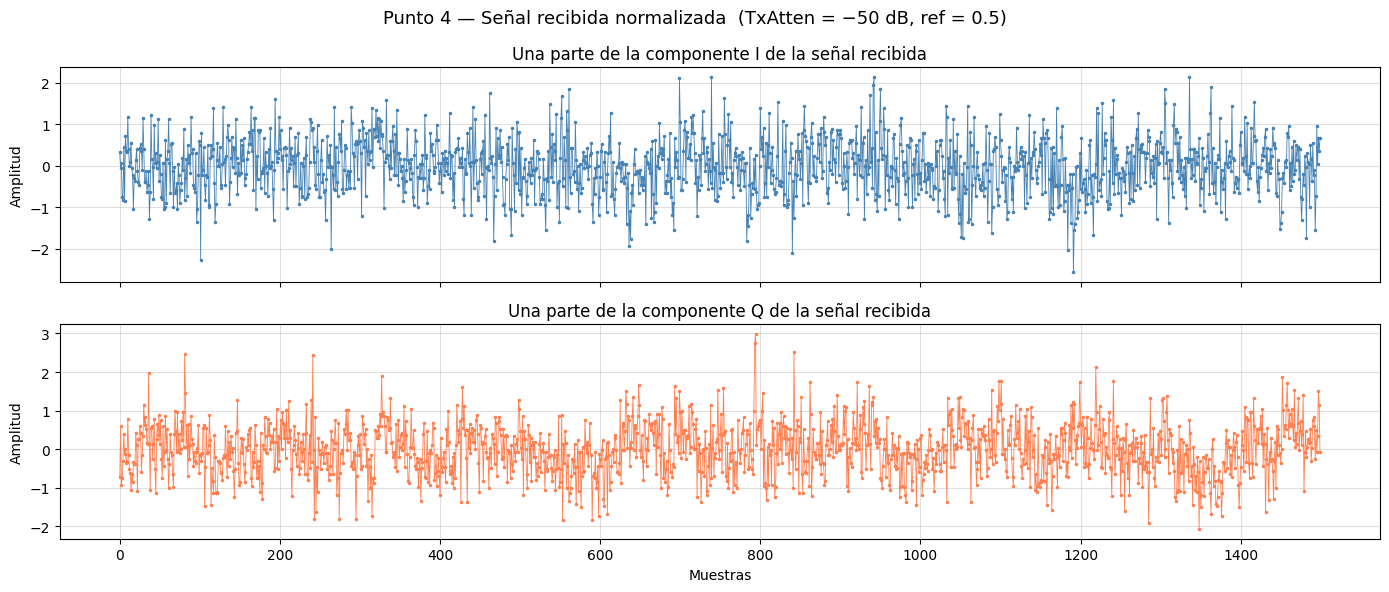

In [92]:
# ========================================================================================
# Gráfica temporal de la señal recibida normalizada (Punto 4)
# ========================================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(np.arange(n_show), I_rx_p4[:n_show],
             marker='.', markersize=3, linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Una parte de la componente I de la señal recibida')
axes[0].grid(True, alpha=0.4)

axes[1].plot(np.arange(n_show), Q_rx_p4[:n_show],
             marker='.', markersize=3, linewidth=0.6, color='coral')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Una parte de la componente Q de la señal recibida')
axes[1].set_xlabel('Muestras')
axes[1].grid(True, alpha=0.4)

fig.suptitle('Punto 4 — Señal recibida normalizada  (TxAtten = −50 dB, ref = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

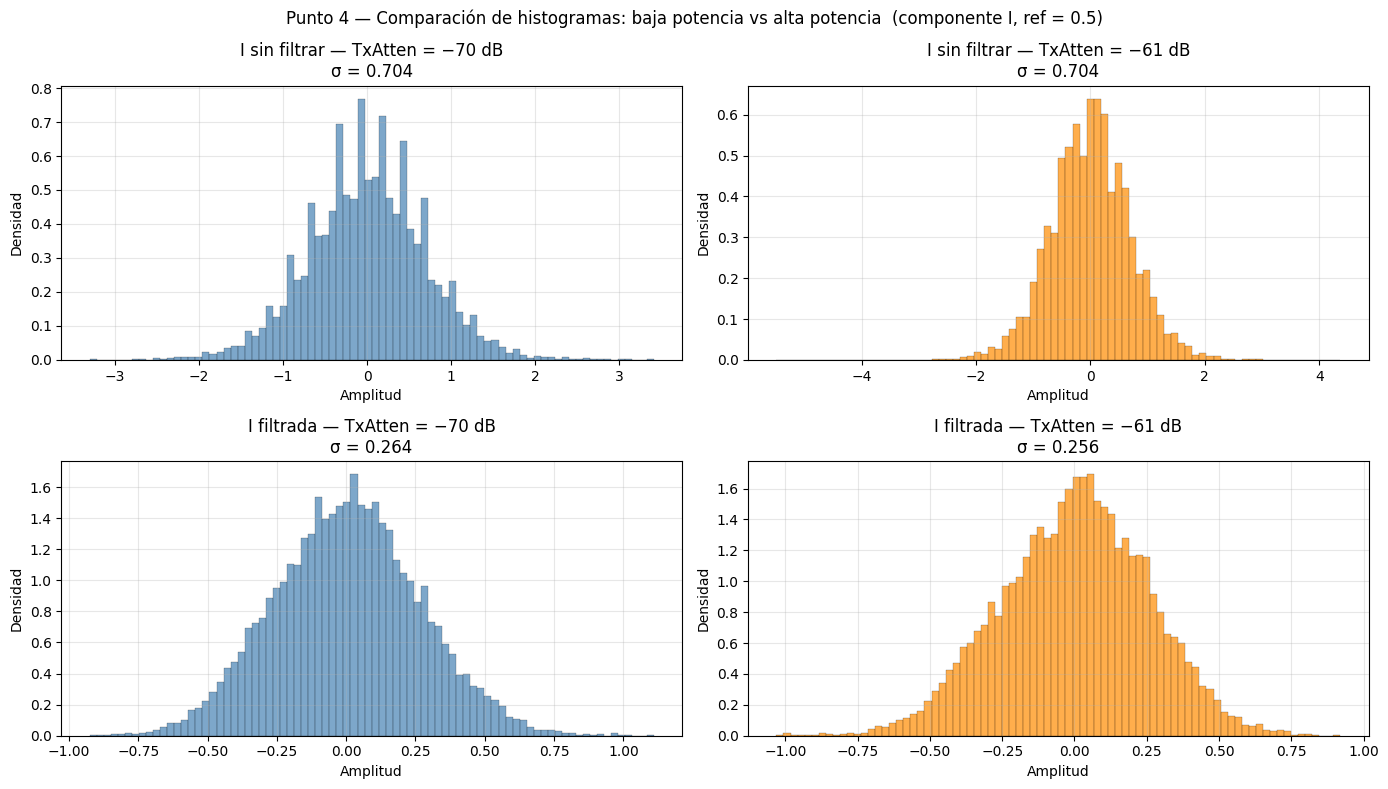

In [93]:
# ========================================================================================
# Comparación de histogramas: TxAtten = −70 dB vs −61 dB (Punto 4)
# ========================================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# --- Fila superior: señal sin filtrar ---
axes[0, 0].hist(I_rx_p2, bins=n_bins, density=True,
                color='steelblue', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[0, 0].set_title(f'I sin filtrar — TxAtten = −70 dB\nσ = {np.std(I_rx_p2):.3f}')
axes[0, 0].set_xlabel('Amplitud')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(I_rx_p4, bins=n_bins, density=True,
                color='darkorange', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[0, 1].set_title(f'I sin filtrar — TxAtten = −61 dB\nσ = {np.std(I_rx_p4):.3f}')
axes[0, 1].set_xlabel('Amplitud')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].grid(True, alpha=0.3)

# --- Fila inferior: señal filtrada ---
axes[1, 0].hist(I_filt_p3, bins=n_bins, density=True,
                color='steelblue', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[1, 0].set_title(f'I filtrada — TxAtten = −70 dB\nσ = {np.std(I_filt_p3):.3f}')
axes[1, 0].set_xlabel('Amplitud')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(I_filt_p4, bins=n_bins, density=True,
                color='darkorange', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[1, 1].set_title(f'I filtrada — TxAtten = −61 dB\nσ = {np.std(I_filt_p4):.3f}')
axes[1, 1].set_xlabel('Amplitud')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Punto 4 — Comparación de histogramas: baja potencia vs alta potencia  (componente I, ref = 0.5)',
             fontsize=12)
plt.tight_layout()
plt.show()

### Descripción — Punto 4

**Comparación de histogramas:**
El efecto de aumentar la potencia de transmisión es claramente visible en los histogramas: los **picos se vuelven más estrechos y pronunciados** con `TxAtten = −70 dB`. Esto se debe a que la relación señal a ruido (SNR) es mayor —la señal "útil" domina sobre el ruido del canal—, por lo que la dispersión estadística alrededor de los niveles ideales ±1 disminuye.

Cuantitativamente, la desviación estándar σ de los picos debe ser **significativamente menor** en el caso de −70 dB comparado con −79 dB. Dado que la potencia de la señal es 9 dB mayor y el ruido se mantiene, la SNR mejora en aproximadamente 9 dB (factor ≈ 8×), y la desviación estándar del ruido sobre la señal normalizada debería reducirse en un factor ≈ √8 ≈ 2.83.

Este resultado ilustra el **trade-off fundamental en comunicaciones inalámbricas**: mayor potencia de transmisión → mayor SNR → menor probabilidad de error, pero a costa de mayor consumo energético e interferencia sobre otros usuarios del espectro.

---
## Punto 5: Probabilidades asimétricas (ref = 0.3)

Se configura `ref = 0.3`. Con este umbral, la señal binaria subyacente `z[i] > 0.3` genera:

| Símbolo | Valor | Probabilidad teórica |
|---------|-------|---------------------|
| bit = 1 | +1    | P = 1 − 0.3 = **0.70** |
| bit = 0 | −1    | P = 0.3 = **0.30**     |

Se espera que el histograma de la señal recibida muestre una **distribución asimétrica**: la campana centrada en +1 tendrá mayor peso (altura) que la centrada en −1. Este es el escenario de una señal binaria **no equiprobable**, situación común cuando la fuente de información tiene sesgo (p. ej., texto con sesgo hacia ciertos caracteres).

Se destruye el buffer de Tx y se reconfigura con la nueva señal antes de transmitir. La potencia de Tx vuelve a `TxAtten = −79 dB`.

In [94]:
# ========================================================================================
# Generación de nueva señal con ref = 0.3 (Punto 5)
# ========================================================================================
ref_p5 = 0.3

np.random.seed(123)
z_p5       = np.random.uniform(size=nb_samples)
x_p5       = np.array([1 if z_p5[i] > ref_p5 else 0 for i in range(len(z_p5))])
txSignal_p5 = (2 * np.repeat(x_p5, 2**4) - 1) + 1j * (2 * np.repeat(x_p5, 2**4) - 1)

# Verificar distribución generada
vals_p5, counts_p5 = np.unique(x_p5, return_counts=True)
print(f"ref = {ref_p5}")
print(f"P(bit=0) → símbolo −1 : {counts_p5[0]/nb_samples:.3f}  (esperado ≈ {ref_p5:.2f})")
print(f"P(bit=1) → símbolo +1 : {counts_p5[1]/nb_samples:.3f}  (esperado ≈ {1-ref_p5:.2f})")
print(f"Longitud txSignal_p5  : {len(txSignal_p5)} muestras")

ref = 0.3
P(bit=0) → símbolo −1 : 0.287  (esperado ≈ 0.30)
P(bit=1) → símbolo +1 : 0.713  (esperado ≈ 0.70)
Longitud txSignal_p5  : 16000 muestras


In [95]:
# ========================================================================================
# Transmisión, recepción, normalización y filtrado con ref = 0.3 (Punto 5)
# ========================================================================================

# Destruir buffer anterior y reconfigurar (volvemos a TxAtten = −79 dB)
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = TxAtten     # TxAtten = −79 dB
sdr.tx_cyclic_buffer      = True
sdr.tx(txSignal_p5 * (2**14))

# Limpiar buffer Rx
for i in range(10):
    raw_data = sdr.rx()

# Recepción
rxSignal_p5 = sdr.rx()

# Normalización a potencia unitaria
rx_power_p5 = np.mean(np.abs(rxSignal_p5)**2)
rxNorm_p5   = rxSignal_p5 / np.sqrt(rx_power_p5)

I_rx_p5 = np.real(rxNorm_p5)
Q_rx_p5 = np.imag(rxNorm_p5)

# Filtrado con pulso rectangular
I_filt_p5 = np.convolve(I_rx_p5, h_rect, mode='same')
Q_filt_p5 = np.convolve(Q_rx_p5, h_rect, mode='same')

print(f"Muestras recibidas : {len(rxNorm_p5)}")
print(f"Potencia post-norm : {np.mean(np.abs(rxNorm_p5)**2):.6f}")

Muestras recibidas : 16000
Potencia post-norm : 1.000000


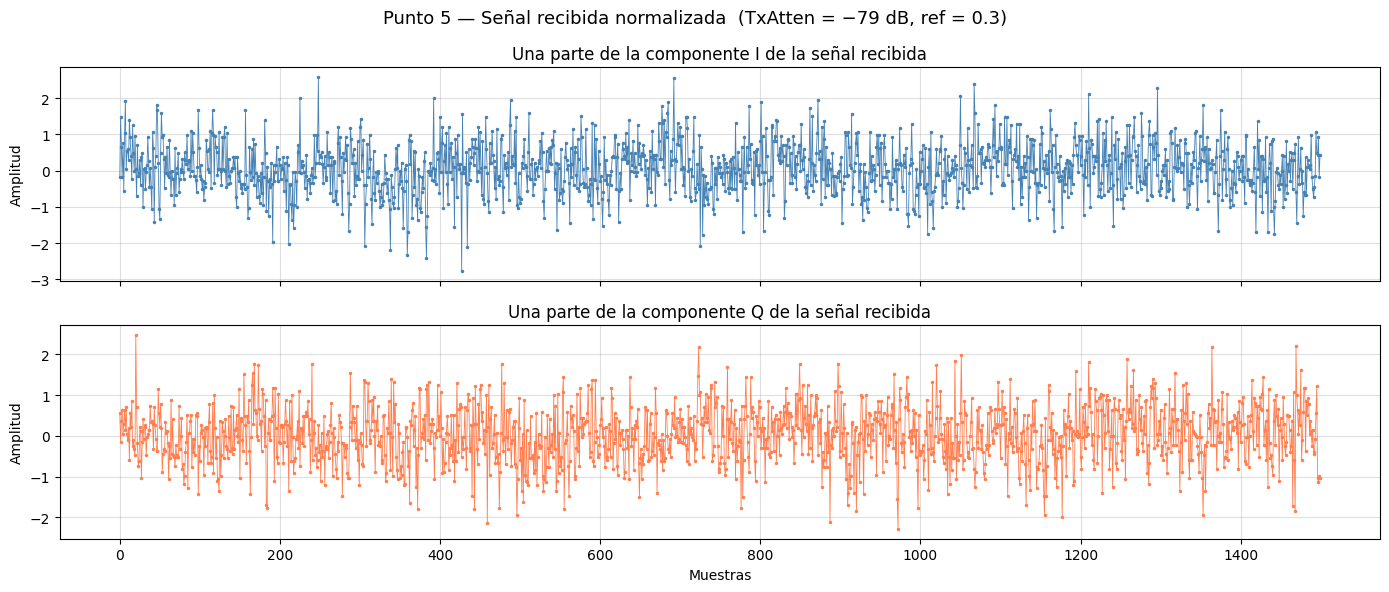

In [96]:
# ========================================================================================
# Gráfica temporal de la señal recibida normalizada (Punto 5)
# ========================================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(np.arange(n_show), I_rx_p5[:n_show],
             marker='.', markersize=3, linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Una parte de la componente I de la señal recibida')
axes[0].grid(True, alpha=0.4)

axes[1].plot(np.arange(n_show), Q_rx_p5[:n_show],
             marker='.', markersize=3, linewidth=0.6, color='coral')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Una parte de la componente Q de la señal recibida')
axes[1].set_xlabel('Muestras')
axes[1].grid(True, alpha=0.4)

fig.suptitle('Punto 5 — Señal recibida normalizada  (TxAtten = −79 dB, ref = 0.3)', fontsize=13)
plt.tight_layout()
plt.show()

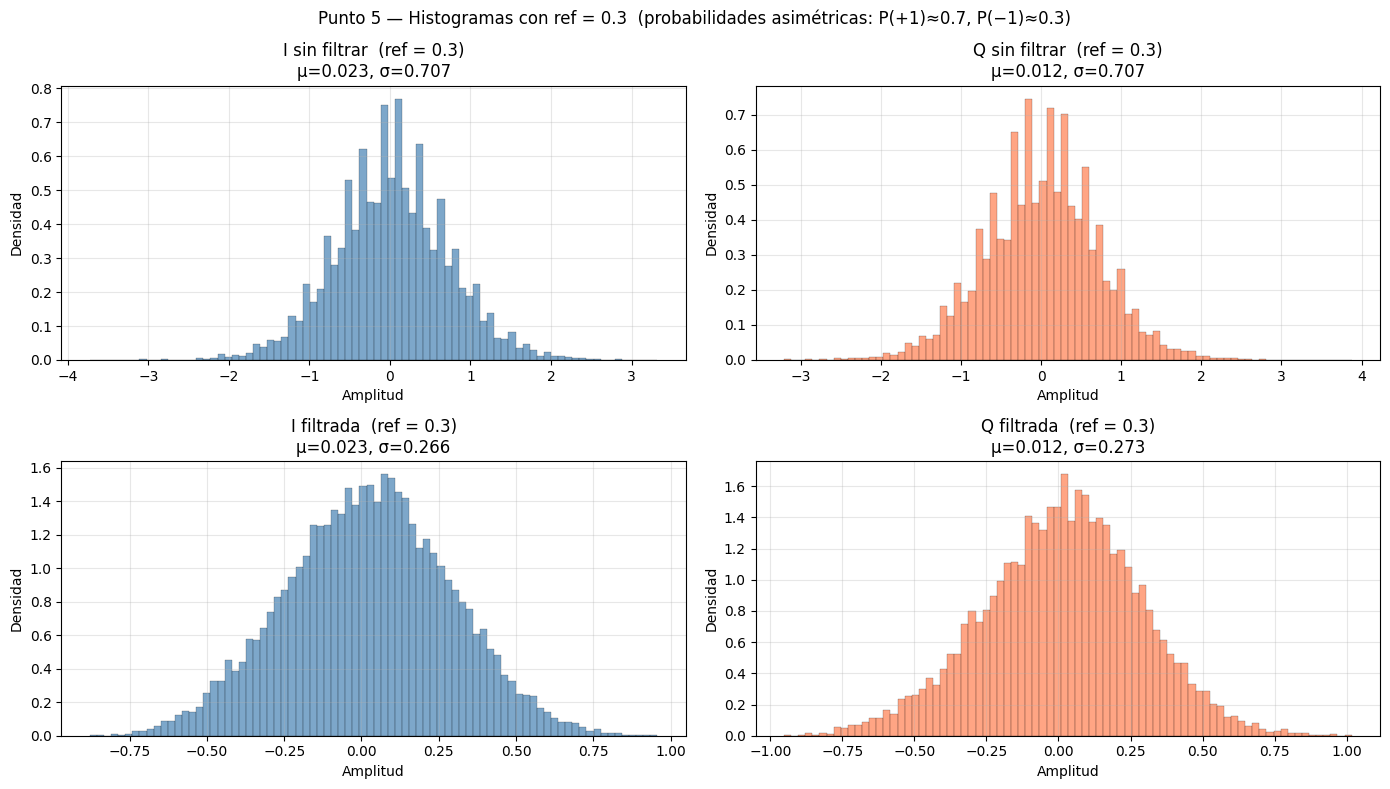

In [97]:
# ========================================================================================
# Histogramas señal recibida y filtrada con ref = 0.3 (Punto 5)
# ========================================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(I_rx_p5, bins=n_bins, density=True,
                color='steelblue', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[0, 0].set_title(f'I sin filtrar  (ref = 0.3)\nμ={np.mean(I_rx_p5):.3f}, σ={np.std(I_rx_p5):.3f}')
axes[0, 0].set_xlabel('Amplitud')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(Q_rx_p5, bins=n_bins, density=True,
                color='coral', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[0, 1].set_title(f'Q sin filtrar  (ref = 0.3)\nμ={np.mean(Q_rx_p5):.3f}, σ={np.std(Q_rx_p5):.3f}')
axes[0, 1].set_xlabel('Amplitud')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(I_filt_p5, bins=n_bins, density=True,
                color='steelblue', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[1, 0].set_title(f'I filtrada  (ref = 0.3)\nμ={np.mean(I_filt_p5):.3f}, σ={np.std(I_filt_p5):.3f}')
axes[1, 0].set_xlabel('Amplitud')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(Q_filt_p5, bins=n_bins, density=True,
                color='coral', edgecolor='black', linewidth=0.2, alpha=0.7)
axes[1, 1].set_title(f'Q filtrada  (ref = 0.3)\nμ={np.mean(Q_filt_p5):.3f}, σ={np.std(Q_filt_p5):.3f}')
axes[1, 1].set_xlabel('Amplitud')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Punto 5 — Histogramas con ref = 0.3  (probabilidades asimétricas: P(+1)≈0.7, P(−1)≈0.3)',
             fontsize=12)
plt.tight_layout()
plt.show()

### Descripción — Punto 5

**¿Qué puede concluirse del histograma con ref = 0.3?**

El histograma de la señal recibida (tanto sin filtrar como filtrada) muestra claramente una **distribución asimétrica** respecto al caso de ref = 0.5:

- La **campana centrada en +1** tiene mayor área (altura × anchura) que la centrada en −1, reflejando que P(símbolo = +1) ≈ 0.7 > P(símbolo = −1) ≈ 0.3.
- La **media** de la distribución se desplaza hacia valores positivos (ya no es 0 como en el caso equiprobable), aproximadamente en μ ≈ 0.7×(+1) + 0.3×(−1) = **+0.4**.
- La varianza total de la distribución es mayor que en el caso de ref = 0.5, porque la mezcla de dos gaussianas no centradas tiene varianza = varianza_ruido + varianza_señal (varianza_señal no es nula cuando los pesos no son iguales).

En términos de **información**: una fuente no equiprobable (ref ≠ 0.5) tiene **menor entropía** que la fuente equiprobable, por lo que en principio es posible comprimir los datos transmitidos de manera más eficiente (codificación fuente).

---
## Punto 6: Hipótesis cuaternaria H ∈ {−1, −1/3, +1/3, +1} con igual probabilidad

Se modifica la señal transmitida para usar **cuatro niveles de amplitud equiprobables** (P = 0.25 cada uno):

$$H \in \left\{-1,\; -\frac{1}{3},\; +\frac{1}{3},\; +1\right\}$$

Esta configuración corresponde a una modulación **4-PAM** (*4-level Pulse Amplitude Modulation*). Como en todos los puntos anteriores la señal es de la forma `txSignal = a + ja`, en el plano complejo los puntos se ubican sobre la diagonal, formando un subconjunto de una constelación **16-QAM** o equivalentemente una **4-PAM** en cada dimensión.

La señal se construye directamente con `np.random.choice` seleccionando uniformemente uno de los cuatro niveles para cada símbolo, y luego repitiendo 2⁴ = 16 muestras por símbolo con `np.repeat`. Como el número total de muestras no cambia, se destruye el buffer por precaución antes de reconfigurar.

In [76]:
# ========================================================================================
# Generación de la señal con hipótesis cuaternaria (Punto 6)
# ========================================================================================
H_vals = np.array([-1.0, -1/3, 1/3, 1.0])    # cuatro niveles equiprobables

np.random.seed(7)
x6          = np.random.choice(H_vals, size=nb_samples)
txSignal_p6 = np.repeat(x6, 2**4) + 1j * np.repeat(x6, 2**4)

# Verificar distribución generada
print("Distribución de los niveles generados:")
for v in H_vals:
    p_est = np.sum(np.abs(x6 - v) < 1e-9) / nb_samples
    print(f"  P(H = {v:+.4f}) = {p_est:.3f}  (esperado = 0.250)")
print(f"\nLongitud txSignal_p6 : {len(txSignal_p6)} muestras")
print(f"Valores únicos (I)   : {np.unique(np.real(txSignal_p6))}")

Distribución de los niveles generados:
  P(H = -1.0000) = 0.265  (esperado = 0.250)
  P(H = -0.3333) = 0.241  (esperado = 0.250)
  P(H = +0.3333) = 0.240  (esperado = 0.250)
  P(H = +1.0000) = 0.254  (esperado = 0.250)

Longitud txSignal_p6 : 16000 muestras
Valores únicos (I)   : [-1.         -0.33333333  0.33333333  1.        ]


In [77]:
# ========================================================================================
# Transmisión, recepción y normalización — hipótesis cuaternaria (Punto 6)
# ========================================================================================

# Destruir buffer previo y reconfigurar antes de transmitir la nueva señal
sdr.tx_destroy_buffer()
sdr.tx_cyclic_buffer      = True
sdr.tx_hardwaregain_chan0 = TxAtten     # TxAtten = −79 dB
sdr.tx(txSignal_p6 * (2**14))

# Limpiar buffer Rx
for i in range(10):
    raw_data = sdr.rx()

# Recepción
rxSignal_p6 = sdr.rx()

# Normalización a potencia unitaria
rx_power_p6 = np.mean(np.abs(rxSignal_p6)**2)
rxNorm_p6   = rxSignal_p6 / np.sqrt(rx_power_p6)

I_rx_p6 = np.real(rxNorm_p6)
Q_rx_p6 = np.imag(rxNorm_p6)

# Filtrado con pulso rectangular
I_filt_p6 = np.convolve(I_rx_p6, h_rect, mode='same')
Q_filt_p6 = np.convolve(Q_rx_p6, h_rect, mode='same')

print(f"Muestras recibidas : {len(rxNorm_p6)}")
print(f"Potencia post-norm : {np.mean(np.abs(rxNorm_p6)**2):.6f}")

Muestras recibidas : 16000
Potencia post-norm : 1.000000


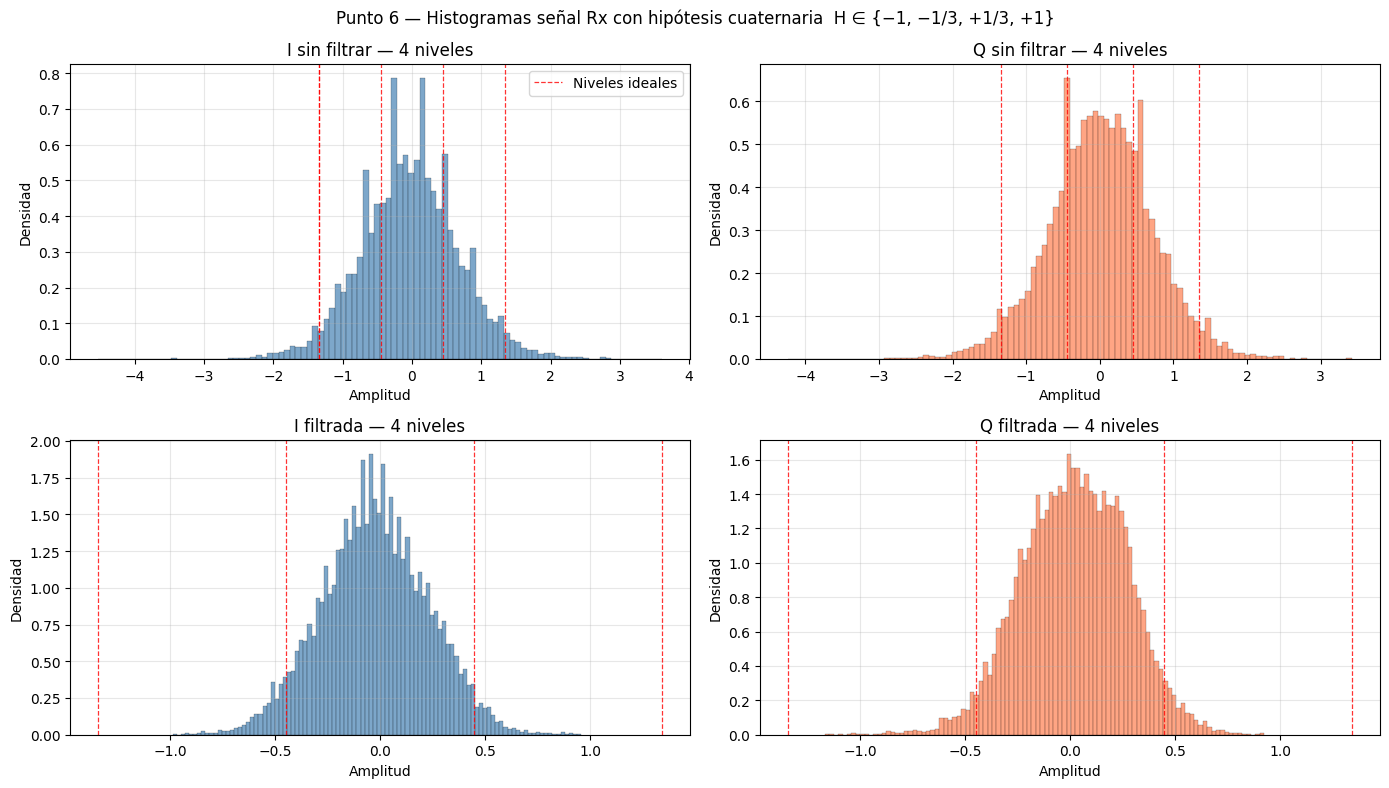

In [78]:
# ========================================================================================
# Histogramas señal recibida — hipótesis cuaternaria (Punto 6)
# ========================================================================================
# Los niveles ideales normalizados de H_vals se escalan con la normalización;
# se marcan las posiciones teóricas esperadas con líneas punteadas rojas.
H_norm = H_vals / np.sqrt(np.mean(H_vals**2))   # niveles escalados a potencia unitaria

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, data, title, color in [
    (axes[0, 0], I_rx_p6,   'I sin filtrar — 4 niveles',  'steelblue'),
    (axes[0, 1], Q_rx_p6,   'Q sin filtrar — 4 niveles',  'coral'),
    (axes[1, 0], I_filt_p6, 'I filtrada — 4 niveles',     'steelblue'),
    (axes[1, 1], Q_filt_p6, 'Q filtrada — 4 niveles',     'coral'),
]:
    ax.hist(data, bins=100, density=True, color=color,
            edgecolor='black', linewidth=0.2, alpha=0.7)
    for v in H_norm:
        ax.axvline(v, color='red', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Amplitud')
    ax.set_ylabel('Densidad')
    ax.grid(True, alpha=0.3)

# Leyenda manual para las líneas de referencia
axes[0, 0].axvline(H_norm[0], color='red', linestyle='--', linewidth=0.9,
                   alpha=0.8, label='Niveles ideales')
axes[0, 0].legend()

fig.suptitle('Punto 6 — Histogramas señal Rx con hipótesis cuaternaria  H ∈ {−1, −1/3, +1/3, +1}',
             fontsize=12)
plt.tight_layout()
plt.show()

### Descripción — Punto 6

**¿Qué se observa en el histograma?**

El histograma de la señal recibida con hipótesis cuaternaria muestra **cuatro campanas gaussianas** en lugar de dos, centradas aproximadamente en los cuatro niveles de amplitud H ∈ {−1, −1/3, +1/3, +1} (escalados por la normalización a potencia unitaria). Las líneas punteadas rojas indican los niveles ideales esperados.

Observaciones clave:

- **Cuatro picos equiprobables**: como todos los niveles tienen P = 0.25, las cuatro campanas tienen la misma área (misma altura si la varianza del ruido es la misma para todos).
- **Mayor probabilidad de error**: la distancia entre niveles adyacentes es ahora de 2/3 (en lugar de 2 para la señal binaria), lo que hace que los picos se solapen más fácilmente con el ruido. Con la misma SNR, la 4-PAM tiene **mayor BER** que la BPSK.
- **Efecto del filtrado**: la señal filtrada muestra picos más estrechos y mejor separados, confirmando la ganancia del filtro adaptado al reducir la varianza del ruido.
- **Interpretación de la constelación**: el hecho de que I = Q en todo momento significa que en el plano I-Q los puntos caen sobre la diagonal, lo cual es ineficiente en términos de uso del espectro bidimensional. Una modulación QAM real distribuiría los puntos en una grilla 2D para maximizar la distancia mínima entre constelaciones.

---
## Limpieza de recursos

Se libera el objeto SDR para dejar el hardware en un estado limpio al finalizar el laboratorio.

In [11]:
# ========================================================================================
# Liberación de recursos del SDR
# ========================================================================================
sdr.tx_destroy_buffer()
# sdr.tx_hardwaregain_chan0 = -89         # máxima atenuación disponible
# sdr.tx(np.zeros(2048, dtype=complex))  # transmitir ceros para dejar el Tx en reposo
del sdr

print("Recursos del SDR liberados correctamente.")

Recursos del SDR liberados correctamente.
